<a href="https://colab.research.google.com/github/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/LSTM_%D0%B4%D0%BB%D1%8F_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%85_%D1%80%D1%8F%D0%B4%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [2]:
passengers_num = np.array(df.Passengers, dtype='float32')

In [3]:
print(type(passengers_num))

<class 'numpy.ndarray'>


In [4]:
len(passengers_num)

144

In [5]:
passengers_num[:5]

array([112., 118., 132., 129., 121.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [6]:
train_size = int(len(passengers_num) * 0.67)

In [7]:
train = passengers_num[:train_size]
test = passengers_num[train_size:]

print(len(train), len(test))

96 48


In [8]:
print(type(train))

<class 'numpy.ndarray'>


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [9]:
import torch

In [10]:
def create_dataset(dataset, lookback):
  X = []
  y = []

  for el in range(len(dataset) - lookback):
    X.append(dataset[el:el + lookback])
    y.append(dataset[el + lookback])

  X = torch.tensor(X)
  y = torch.tensor(y).unsqueeze(1)

  return X, y

In [11]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


/tmp/ipykernel_10852/4287594693.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X)


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [12]:
import torch.nn as nn

In [13]:
class AirModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(AirModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)


    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])

        return out

In [14]:
input_size = 1
hidden_size = 50
num_layers = 1
model = AirModel(input_size, hidden_size, num_layers)
model

AirModel(
  (rnn): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [15]:
model(torch.tensor([[112.]]).unsqueeze(2))

tensor([[0.0311]], grad_fn=<AddmmBackward0>)

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [16]:
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

In [17]:
train_ds = TensorDataset(X_train, y_train)

batch_size = 8
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
next(iter(train_dl))

[tensor([[293.],
         [229.],
         [237.],
         [315.],
         [171.],
         [191.],
         [181.],
         [242.]]),
 tensor([[259.],
         [243.],
         [211.],
         [364.],
         [180.],
         [172.],
         [183.],
         [209.]])]

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [18]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_iters = 2000
print_every = 100


def calc_predict(model, loss_fn, optimizer, n_iters, print_every):
  losses = []

  for iter in range(n_iters):
    total_loss = 0

    for X, y in train_dl:

      optimizer.zero_grad()

      pred = model(X.unsqueeze(2))
      loss = loss_fn(pred, y)

      loss.backward()
      optimizer.step()

      total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    losses.append(avg_loss)

    if iter % print_every == 0:
      with torch.no_grad():
        model.eval()
        train_pred = model(X_train.unsqueeze(2))
        train_rmse = np.sqrt(loss_fn(train_pred, y_train).item())
        test_pred = model(X_test.unsqueeze(2))
        test_rmse = np.sqrt(loss_fn(test_pred, y_test).item())
      model.train()
      print( f"Epoch {iter}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

  return losses

losses= calc_predict(model, loss_fn, optimizer, n_iters, print_every)

Epoch 0: train RMSE 225.8748, test RMSE 422.2644
Epoch 100: train RMSE 189.1172, test RMSE 383.8495
Epoch 200: train RMSE 158.7719, test RMSE 351.3078
Epoch 300: train RMSE 131.9418, test RMSE 321.3084
Epoch 400: train RMSE 108.9189, test RMSE 293.5814
Epoch 500: train RMSE 90.5385, test RMSE 268.4397
Epoch 600: train RMSE 74.3195, test RMSE 244.5241
Epoch 700: train RMSE 60.6942, test RMSE 221.7930
Epoch 800: train RMSE 49.8019, test RMSE 201.0891
Epoch 900: train RMSE 41.6147, test RMSE 182.4351
Epoch 1000: train RMSE 35.7831, test RMSE 165.9017
Epoch 1100: train RMSE 31.5709, test RMSE 152.0055
Epoch 1200: train RMSE 29.0542, test RMSE 139.9852
Epoch 1300: train RMSE 27.0295, test RMSE 130.6191
Epoch 1400: train RMSE 25.9599, test RMSE 123.3217
Epoch 1500: train RMSE 25.8358, test RMSE 117.1223
Epoch 1600: train RMSE 26.1222, test RMSE 113.4887
Epoch 1700: train RMSE 24.5911, test RMSE 108.9681
Epoch 1800: train RMSE 24.5819, test RMSE 106.3831
Epoch 1900: train RMSE 24.0443, test R

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

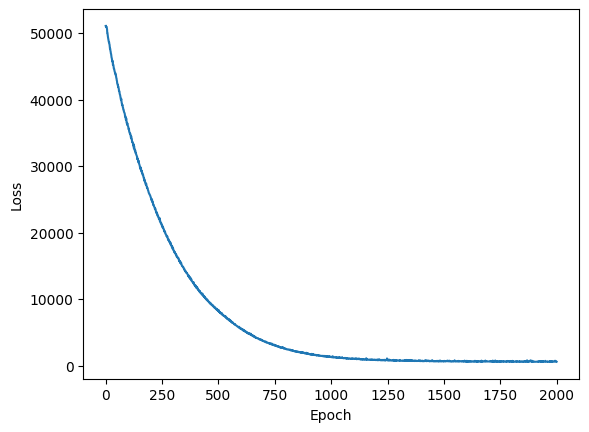

In [19]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

***Висновок:***
- Графік показує, що модель навчилась. RMSE стабільно зменшується з кожною епохою.

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

In [20]:
timeseries = passengers_num

/tmp/ipykernel_10852/3903738449.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train.unsqueeze(2))[:, -1]
/tmp/ipykernel_10852/3903738449.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test.unsqueeze(2))[:, -1]


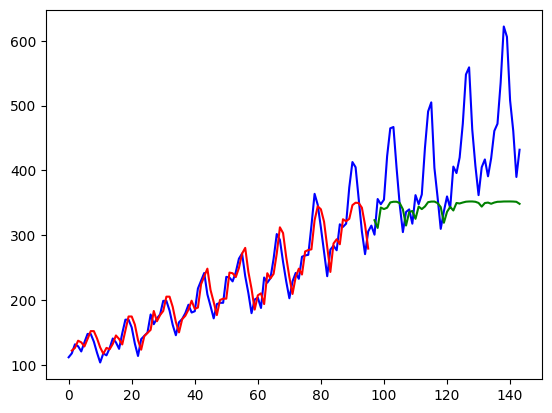

In [21]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      #y_pred = model(X_train)
      y_pred = model(X_train.unsqueeze(2))
      y_pred = y_pred[:, -1]
      #train_plot[lookback:train_size] = model(X_train)[:, -1]
      train_plot[lookback:train_size] = model(X_train.unsqueeze(2))[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      #test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]
      test_plot[train_size+lookback:len(timeseries)] = model(X_test.unsqueeze(2))[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

Epoch 0: train RMSE 226.0349, test RMSE 422.4724
Epoch 100: train RMSE 144.1457, test RMSE 335.1548
Epoch 200: train RMSE 95.4312, test RMSE 275.4231
Epoch 300: train RMSE 66.3061, test RMSE 230.8891
Epoch 400: train RMSE 47.3697, test RMSE 194.5054
Epoch 500: train RMSE 35.7846, test RMSE 165.7426
Epoch 600: train RMSE 29.7723, test RMSE 143.6876
Epoch 700: train RMSE 26.8937, test RMSE 126.8238
Epoch 800: train RMSE 25.6947, test RMSE 116.1464
Epoch 900: train RMSE 25.0496, test RMSE 107.8330
Epoch 1000: train RMSE 23.6486, test RMSE 101.6600
Epoch 1100: train RMSE 23.8102, test RMSE 97.7196
Epoch 1200: train RMSE 23.9263, test RMSE 93.8524
Epoch 1300: train RMSE 23.3276, test RMSE 91.9653
Epoch 1400: train RMSE 23.4504, test RMSE 90.3239
Epoch 1500: train RMSE 24.9407, test RMSE 87.9641
Epoch 1600: train RMSE 22.9567, test RMSE 87.4071
Epoch 1700: train RMSE 25.8472, test RMSE 90.6614
Epoch 1800: train RMSE 23.1145, test RMSE 84.5204
Epoch 1900: train RMSE 22.9017, test RMSE 85.0171

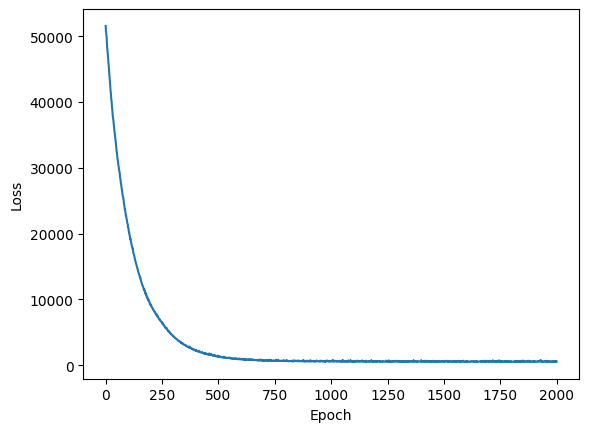

/tmp/ipykernel_10852/3903738449.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train.unsqueeze(2))[:, -1]
/tmp/ipykernel_10852/3903738449.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test.unsqueeze(2))[:, -1]


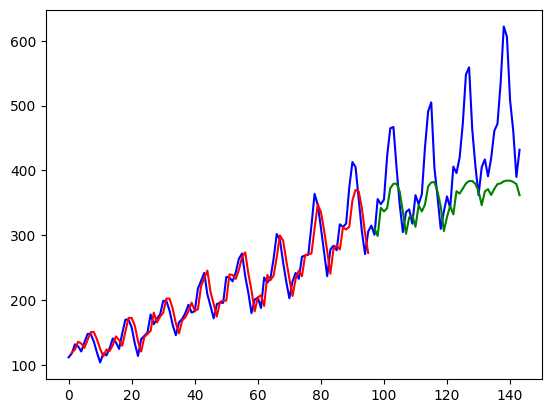

In [22]:
hidden_size = 100

model = AirModel(input_size, hidden_size, num_layers)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
losses_100 = calc_predict(model, loss_fn, optimizer, n_iters, print_every)

plt.plot(losses_100)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plot_predicts()

***Висновок:***
- Графік лосів показує, що модель навчилась. RMSE стабільно зменшується з кожною епохою.
- Ознаки перенавчання трохи зменшилися, але це не сильно покращило результат.
- Графік відображення роботи моделі на тренувальних та тестових даних ткож дещо покращився.